<a href="https://colab.research.google.com/github/alexanderson522/INFO648/blob/main/Homeworks/Homework_3/INFO648_Problem_Set_3_Alex_Anderson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part A - Winsorization (Outlier Handling)

In [45]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns

In [46]:
#read in data
df=pd.read_csv('/content/cps_with_education.csv')
df.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,0,2020,40,0.0,63,2,23,Some College
1,1,2020,999,0.0,67,1,23,Some College
2,2,2020,48,654.0,64,1,23,Some College
3,3,2020,999,0.0,71,2,23,Less than HS
4,4,2020,44,0.0,54,2,23,Some College


Since this is the same data set as the previous problem set, there are invalid rows present in the data. We will clean the data by:
- removing all rows where earnings are 999999.99 or non-positive
- remove rows where hours worked exceeds total hours in a week (168 hours)
- Keep only observations from 2024 and 2025

In [47]:
df_clean=df[(df["EARNWEEK2"]<999999)&
    (df["EARNWEEK2"] > 0)].copy()
df_clean=df_clean[df_clean['UHRSWORKT']<168].copy() #only 168 hours in a week
df_clean=df_clean[(df_clean['YEAR']==2024) | (df_clean['YEAR']==2025)].copy()
df_clean.head()


,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076326,3076326,2024,40,520.0,36,1,1,Some College
3076330,3076330,2024,40,700.0,23,2,1,Some College
3076332,3076332,2024,35,516.0,64,2,1,Some College
3076333,3076333,2024,40,720.0,57,2,1,Some College
3076334,3076334,2024,12,220.0,69,1,1,Some College


In [48]:
#Create 4 groups: Men-2024, Men-2025, Women-2024, Women-2025
men_2024=df_clean[(df_clean['SEX']==1) & (df_clean['YEAR']==2024)].copy()
men_2025=df_clean[(df_clean['SEX']==1) & (df_clean['YEAR']==2025)].copy()
women_2024=df_clean[(df_clean['SEX']==2) & (df_clean['YEAR']==2024)].copy()
women_2025=df_clean[(df_clean['SEX']==2) & (df_clean['YEAR']==2025)].copy()


In [49]:
men_2024.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076326,3076326,2024,40,520.0,36,1,1,Some College
3076334,3076334,2024,12,220.0,69,1,1,Some College
3076344,3076344,2024,40,2880.0,64,1,1,Graduate / Professional
3076347,3076347,2024,60,1730.0,58,1,1,Some College
3076349,3076349,2024,40,880.0,47,1,1,Bachelor's


In [50]:
men_2025.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
4369979,4369979,2025,40,760.0,65,1,5,Some College
4369981,4369981,2025,38,1650.0,41,1,2,Master's
4370050,4370050,2025,40,962.0,36,1,1,Graduate / Professional
4370063,4370063,2025,40,660.0,26,1,5,Associate's
4370069,4370069,2025,36,1690.0,36,1,42,Some College


In [51]:
women_2024.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
3076330,3076330,2024,40,700.0,23,2,1,Some College
3076332,3076332,2024,35,516.0,64,2,1,Some College
3076333,3076333,2024,40,720.0,57,2,1,Some College
3076345,3076345,2024,40,654.0,60,2,1,Associate's
3076346,3076346,2024,20,300.0,18,2,1,Some College


In [52]:
women_2025.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
4369980,4369980,2025,40,734.0,59,2,5,Some College
4369985,4369985,2025,30,570.0,33,2,8,Bachelor's
4369992,4369992,2025,40,1046.0,36,2,6,Master's
4370049,4370049,2025,10,480.0,36,2,1,Master's
4370064,4370064,2025,35,466.0,25,2,5,Associate's


In [53]:
#Windsorization; find 95th percentile cutoff for each of the four groups
men_2024_cutoff=men_2024['EARNWEEK2'].quantile(0.95)
men_2025_cutoff=men_2025['EARNWEEK2'].quantile(0.95)
women_2024_cutoff=women_2024['EARNWEEK2'].quantile(0.95)
women_2025_cutoff=women_2025['EARNWEEK2'].quantile(0.95)

In [54]:
#Create a new column called EARNWEEK2_w95 using cutoff value.
#If the EARNWEEK2 value at the location is greater than the cutoff value, change the EARNWEEK2_w95 columns value
men_2024['EARNWEEK2_w95']=men_2024['EARNWEEK2']
men_2024.loc[men_2024['EARNWEEK2']>men_2024_cutoff,'EARNWEEK2_w95']=men_2024_cutoff

men_2025['EARNWEEK2_w95']=men_2025['EARNWEEK2']
men_2025.loc[men_2025['EARNWEEK2']>men_2025_cutoff,'EARNWEEK2_w95']=men_2025_cutoff

women_2024['EARNWEEK2_w95']=women_2024['EARNWEEK2']
women_2024.loc[women_2024['EARNWEEK2']>women_2024_cutoff,'EARNWEEK2_w95']=women_2024_cutoff

women_2025['EARNWEEK2_w95']=women_2025['EARNWEEK2']
women_2025.loc[women_2025['EARNWEEK2']>women_2025_cutoff,'EARNWEEK2_w95']=women_2025_cutoff

In [55]:
# Create a DataFrame to display the cutoffs and winsorized sample sizes

# Calculate the number of winsorized rows for each group
men_2024_winsorized_count = (men_2024['EARNWEEK2'] > men_2024_cutoff).sum()
men_2025_winsorized_count = (men_2025['EARNWEEK2'] > men_2025_cutoff).sum()
women_2024_winsorized_count = (women_2024['EARNWEEK2'] > women_2024_cutoff).sum()
women_2025_winsorized_count = (women_2025['EARNWEEK2'] > women_2025_cutoff).sum()

group_data = {
    'Group': ['Men-2024', 'Men-2025', 'Women-2024', 'Women-2025'],
    'Cutoff': [men_2024_cutoff, men_2025_cutoff, women_2024_cutoff, women_2025_cutoff],
    'Sample Size': [len(men_2024), len(men_2025), len(women_2024), len(women_2025)],
    'Winsorized Rows': [
        men_2024_winsorized_count,
        men_2025_winsorized_count,
        women_2024_winsorized_count,
        women_2025_winsorized_count
    ]
}

winsor_summary_df = pd.DataFrame(group_data)
display(winsor_summary_df)

,Group,Cutoff,Sample Size,Winsorized Rows
0,Men-2024,3660.0,63274,3116
1,Men-2025,3880.0,53157,2656
2,Women-2024,2880.0,60949,2946
3,Women-2025,2980.0,51170,2536


The Men-2024 cutoff is 3660 and the sample size is 63,274, with 3116 rows being winsorized. The Men-2025 cutoff is 3880 and the sample size is 53,157, with 2656 rows being winsorized. The Women-2024 cutoff is 2880 and sample size is 60,949, with 2946 rows being winsorized. The Women-2025 cutoff is 2980 and sample size is 51,170, with 2536 rows being winsorized.

#Part B - Confidence Intervals for Population Mean Earnings

In [56]:
#Compute mean and standard deviation of each group
men_2024_mean=men_2024['EARNWEEK2_w95'].mean()
men_2024_std=men_2024['EARNWEEK2_w95'].std()

men_2025_mean=men_2025['EARNWEEK2_w95'].mean()
men_2025_std=men_2025['EARNWEEK2_w95'].std()

women_2024_mean=women_2024['EARNWEEK2_w95'].mean()
women_2024_std=women_2024['EARNWEEK2_w95'].std()

women_2025_mean=women_2025['EARNWEEK2_w95'].mean()
women_2025_std=women_2025['EARNWEEK2_w95'].std()

In [57]:
#compute 95% CI for each group
z=norm.ppf(1-0.025)

men_2024_ci_lower=men_2024_mean-z*(men_2024_std/np.sqrt(len(men_2024)))
men_2024_ci_upper=men_2024_mean+z*(men_2024_std/np.sqrt(len(men_2024)))

men_2025_ci_lower=men_2025_mean-z*(men_2025_std/np.sqrt(len(men_2025)))
men_2025_ci_upper=men_2025_mean+z*(men_2025_std/np.sqrt(len(men_2025)))

women_2024_ci_lower=women_2024_mean-z*(women_2024_std/np.sqrt(len(women_2024)))
women_2024_ci_upper=women_2024_mean+z*(women_2024_std/np.sqrt(len(women_2024)))

women_2025_ci_lower=women_2025_mean-z*(women_2025_std/np.sqrt(len(women_2025)))
women_2025_ci_upper=women_2025_mean+z*(women_2025_std/np.sqrt(len(women_2025)))

In [58]:
#Display confidence interval for each group
ci_data = {
    'Group': ['Men-2024', 'Men-2025', 'Women-2024', 'Women-2025'],
    'Conf. Int. Lower': [men_2024_ci_lower, men_2025_ci_lower, women_2024_ci_lower, women_2025_ci_lower],
    'Conf. Int. Upper': [men_2024_ci_upper, men_2025_ci_upper, women_2024_ci_upper, women_2025_ci_upper],
}

summary_df = pd.DataFrame(ci_data)
display(summary_df)

,Group,Conf. Int. Lower,Conf. Int. Upper
0,Men-2024,1412.607246,1426.797761
1,Men-2025,1487.201432,1503.832284
2,Women-2024,1097.480629,1108.903523
3,Women-2025,1137.105934,1150.049728


These intervals mean that we are 95% confident that the population's mean earnings for each group falls between the listed lower and upper interval:
- Men-2024: (1412.61,1426.80)
- Men-2025: (1487.20, 1503.83)
- Women-2024: (1097.48, 1108.90)
- Women-2025: (1137.11, 1150.05)

When comparing the different years within both men and women, we can see that there is no overlap in the confidence intervals between 2024 and 2025 for each group. In fact, the upper limit for 2024 is less than the lower limit for 2025 for both men and women. This strongly suggests that the mean earnings for 2025 men/women is higher than their 2024 counterpart.

# Part C — Hypothesis Tests: Did the Population Mean Change?

In [59]:
#Run Hypothesis test for men-2024 vs men-2025
#Ho: mu(men_2024 Earnings) = mu(men_2025 Earnings)
#Ha: mu(men_2024 Earnings) != mu(men_2025 Earnings)
t_stat, p_value = ttest_ind(men_2024['EARNWEEK2_w95'], men_2025['EARNWEEK2_w95'])
mean_diff=men_2025_mean-men_2024_mean
print("Men 2024 Mean:", men_2024_mean)
print("Men 2025 Mean:", men_2025_mean)
print("Sample winsorized Mean difference:", mean_diff)
print("T-statistic:", t_stat)
print("P-value:", p_value)

Men 2024 Mean: 1419.7025035559632
Men 2025 Mean: 1495.5168576104745
Sample winsorized Mean difference: 75.81435405451134
T-statistic: -13.678296375486397
P-value: 1.4765154550244485e-42


The Men 2024 winsorized mean is 1419.70 and Men 2025 mean is 1495.52, giving us a mean difference of 75.81.

Our null and alternative hypotheses are:
$$
H_0:\ \mu_{\text{Men_2024}} = \mu_{\text{Men_2025}}
$$

$$
H_a:\ \mu_{\text{Men_2024}} \neq \mu_{\text{Men_2025}}
$$

The p-value from this t-test is 1.48e-42, which is effectively zero.

##Interpretation
The p-value is below the 0.05 threshold, therefore we reject the null. We can conclude that the population mean of earnings for men in 2024 is not equal to the mean of earnings for men in 2025.



In [60]:
#Run Hypothesis test for women-2024 vs women-2025
#Ho: mu(women_2024 Earnings) = mu(women_2025 Earnings)
#Ha: mu(women_2024 Earnings) != mu(women_2025 Earnings)
t_stat, p_value = ttest_ind(women_2024['EARNWEEK2_w95'], women_2025['EARNWEEK2_w95'])
mean_diff=women_2025_mean-women_2024_mean
print("Women 2024 Mean:", women_2024_mean)
print("Women 2025 Mean:", women_2025_mean)
print("Sample winsorized Mean difference:", mean_diff)
print("T-statistic:", t_stat)
print("P-value:", p_value)

Women 2024 Mean: 1103.1920759979655
Women 2025 Mean: 1143.5778307602109
Sample winsorized Mean difference: 40.38575476224537
T-statistic: -9.200306932306233
P-value: 3.628102020930496e-20


The Women 2024 winsorized mean is 1103.19 and Women 2025 mean is 1143.58, giving us a mean difference of 40.39.

Our null and alternative hypotheses are:
$$
H_0:\ \mu_{\text{Women_2024}} = \mu_{\text{Women_2025}}
$$

$$
H_a:\ \mu_{\text{Women_2024}} \neq \mu_{\text{Women_2025}}
$$

The p-value from this t-test is 3.63e-20, which is effectively zero.

##Interpretation
The p-value is below the 0.05 threshold, therefore we reject the null. We can conclude that the population mean of earnings for women in 2024 is not equal to the mean of earnings for women in 2025.



#Part D - Statistical vs. Practical Significance

In [61]:
#For each sex, compute the percent change in the winsorized mean
men_percent_change=(men_2025_mean-men_2024_mean)/men_2024_mean*100
women_percent_change=(women_2025_mean-women_2024_mean)/women_2024_mean*100
print(f"Men Percent Change: {men_percent_change:.2f}%")
print(f"Women Percent Change: {women_percent_change:.2f}%")

Men Percent Change: 5.34%
Women Percent Change: 3.66%


In [62]:
#For each sex, compute Cohen’s d using the pooled standard deviation

# Men
# Calculate pooled standard deviation for men
n1_men = len(men_2024)
n2_men = len(men_2025)
s1_men = men_2024_std
s2_men = men_2025_std

sp_men = np.sqrt(((n1_men - 1) * s1_men**2 + (n2_men - 1) * s2_men**2) / (n1_men + n2_men - 2))

# Calculate Cohen's d for men
cohens_d_men = (men_2025_mean - men_2024_mean) / sp_men

# Women
# Calculate pooled standard deviation for women
n1_women = len(women_2024)
n2_women = len(women_2025)
s1_women = women_2024_std
s2_women = women_2025_std

sp_women = np.sqrt(((n1_women - 1) * s1_women**2 + (n2_women - 1) * s2_women**2) / (n1_women + n2_women - 2))

# Calculate Cohen's d for women
cohens_d_women = (women_2025_mean - women_2024_mean) / sp_women

print(f"Cohen's d for Men: {cohens_d_men}")
print(f"Cohen's d for Women: {cohens_d_women}")

Cohen's d for Men: 0.08047730915554958
Cohen's d for Women: 0.0551633869297983


The percentage change from 2024 to 2025 mean weekly earnings is 5.34% for men and 3.66% for women. Cohen's d is 0.08 for men and 0.055 for women.

Both of these Cohen's d values would be classified as a **small** effect. The p-value is so small likely because our sample size for each group is very large; *any* difference in the mean would result in a small p-value with the sample sizes we're using here. While the difference in the mean weekly earnings are statistically significant, meaning there is a measureable difference between the means, it is not very practically significant according to our Cohen's d values, meaning the true difference is small and likely doesn't carry much real-world significance.

#Part E - CPI Check: Are Earnings “Keeping Up”?

The percentage change from 2024 to 2025 mean weekly earnings is 5.34% for men and 3.66% for women. If inflation was 2.7% from 2024 to 2025, this means that the mean weekly earnings for both men and women are going beyond "keeping up" and are actually outpacing inflation. According to this sample, men are exceeding the inflation rate at a higher rate than women. It is important to take into account that this is just the mean weekly earnings, this does not mean that every individual in the sample is keeping up with inflation.

#Part F - Plots

### Histograms of Winsorized Weekly Earnings by Sex and Year

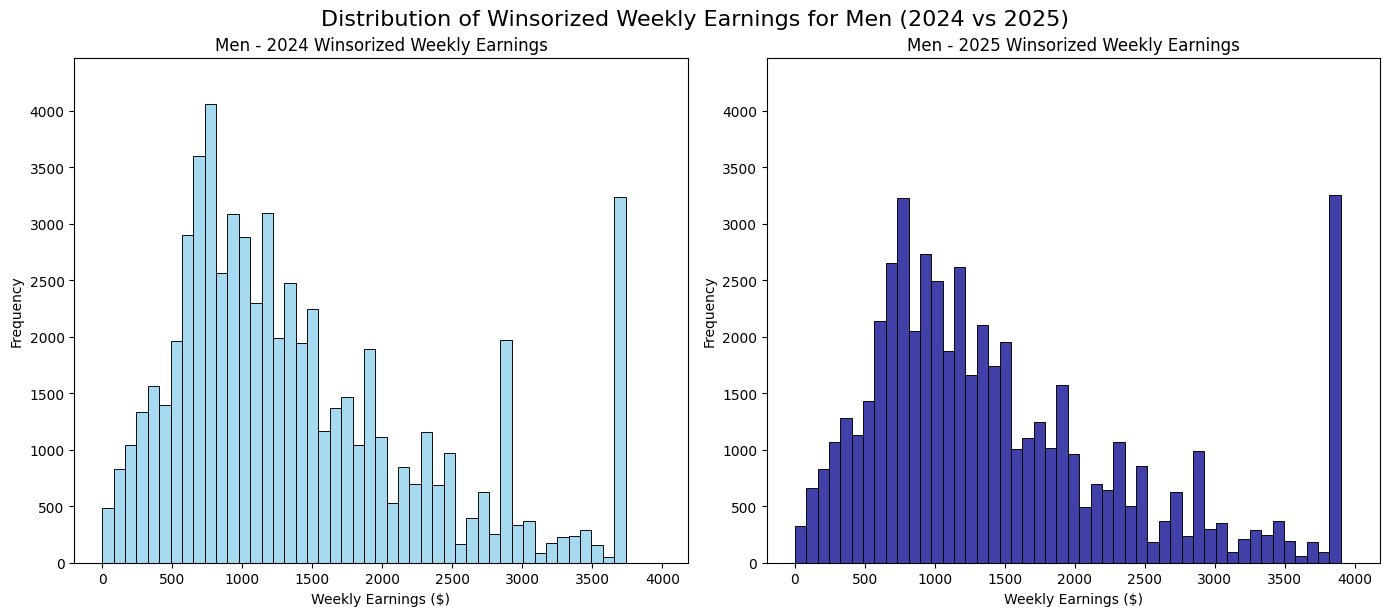

In [63]:
# Determine a reasonable common bin range for men
men_max_earnings = max(men_2024['EARNWEEK2_w95'].max(), men_2025['EARNWEEK2_w95'].max())
men_bins = np.linspace(0, men_max_earnings + 100, 50)

# Calculate max frequency across both years for men to synchronize y-axis
men_hist_2024, _ = np.histogram(men_2024['EARNWEEK2_w95'], bins=men_bins)
men_hist_2025, _ = np.histogram(men_2025['EARNWEEK2_w95'], bins=men_bins)
men_max_freq = max(men_hist_2024.max(), men_hist_2025.max())

# Plotting for Men
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(men_2024['EARNWEEK2_w95'], bins=men_bins, kde=False, color='skyblue')
plt.title('Men - 2024 Winsorized Weekly Earnings')
plt.xlabel('Weekly Earnings ($)')
plt.ylabel('Frequency')
plt.ylim(0, men_max_freq * 1.1) # Add some padding to the max frequency

plt.subplot(1, 2, 2)
sns.histplot(men_2025['EARNWEEK2_w95'], bins=men_bins, kde=False, color='darkblue')
plt.title('Men - 2025 Winsorized Weekly Earnings')
plt.xlabel('Weekly Earnings ($)')
plt.ylabel('Frequency')
plt.ylim(0, men_max_freq * 1.1) # Add some padding to the max frequency

plt.tight_layout()
plt.suptitle('Distribution of Winsorized Weekly Earnings for Men (2024 vs 2025)', y=1.02, fontsize=16)
plt.show()

For men in 2024 and 2025, we can see that both years skew right, which almost certainly pulls the mean weekly earnings further to the right than the median. We can also see a large spike at the winsorized limit for each year, meaning a large number of observations exceeded our winsorized value.

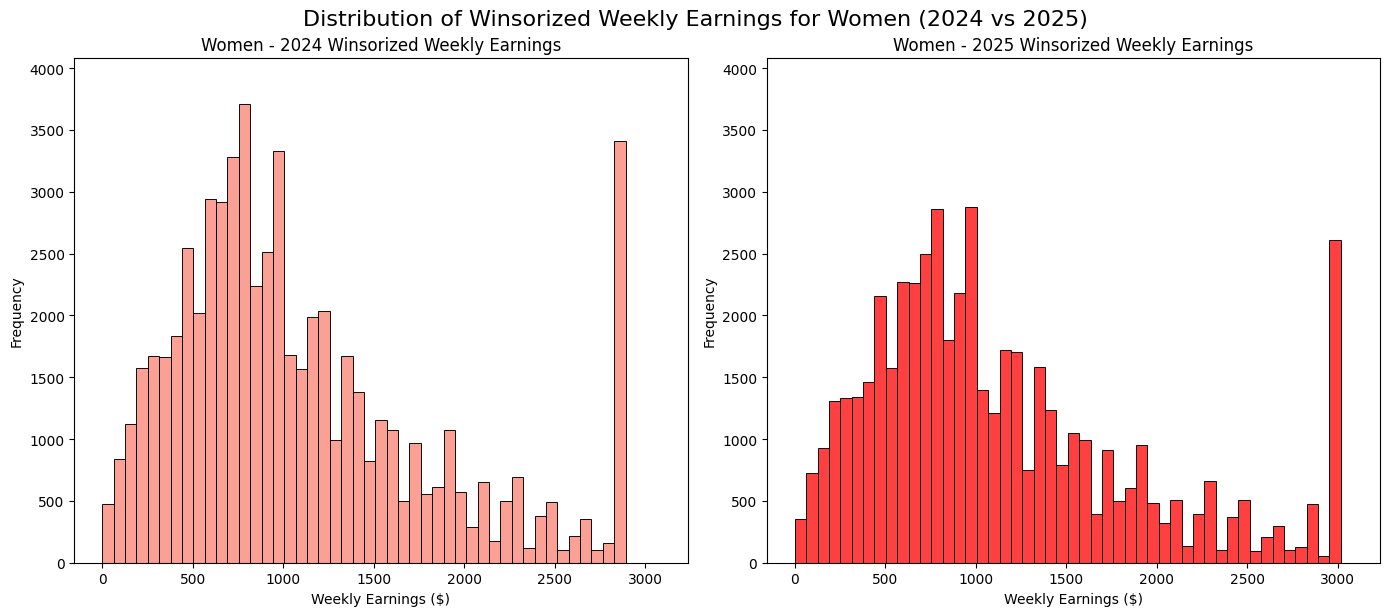

In [64]:

# Determine a reasonable common bin range for women
women_max_earnings = max(women_2024['EARNWEEK2_w95'].max(), women_2025['EARNWEEK2_w95'].max())
women_bins = np.linspace(0, women_max_earnings + 100, 50)

# Calculate max frequency across both years for women to synchronize y-axis
women_hist_2024, _ = np.histogram(women_2024['EARNWEEK2_w95'], bins=women_bins)
women_hist_2025, _ = np.histogram(women_2025['EARNWEEK2_w95'], bins=women_bins)
women_max_freq = max(women_hist_2024.max(), women_hist_2025.max())

# Plotting for Women
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(women_2024['EARNWEEK2_w95'], bins=women_bins, kde=False, color='salmon')
plt.title('Women - 2024 Winsorized Weekly Earnings')
plt.xlabel('Weekly Earnings ($)')
plt.ylabel('Frequency')
plt.ylim(0, women_max_freq * 1.1) # Add some padding to the max frequency

plt.subplot(1, 2, 2)
sns.histplot(women_2025['EARNWEEK2_w95'], bins=women_bins, kde=False, color='red')
plt.title('Women - 2025 Winsorized Weekly Earnings')
plt.xlabel('Weekly Earnings ($)')
plt.ylabel('Frequency')
plt.ylim(0, women_max_freq * 1.1) # Add some padding to the max frequency

plt.tight_layout()
plt.suptitle('Distribution of Winsorized Weekly Earnings for Women (2024 vs 2025)', y=1.02, fontsize=16)
plt.show()

The histograms for women in 2024 and 2025 tell a similar story as the men histograms. Both years skew to the right, with a large bump at the winsorized limit.

### Winsorized Mean Weekly Earnings with 95% Confidence Intervals

/tmp/ipykernel_31476/1385088149.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


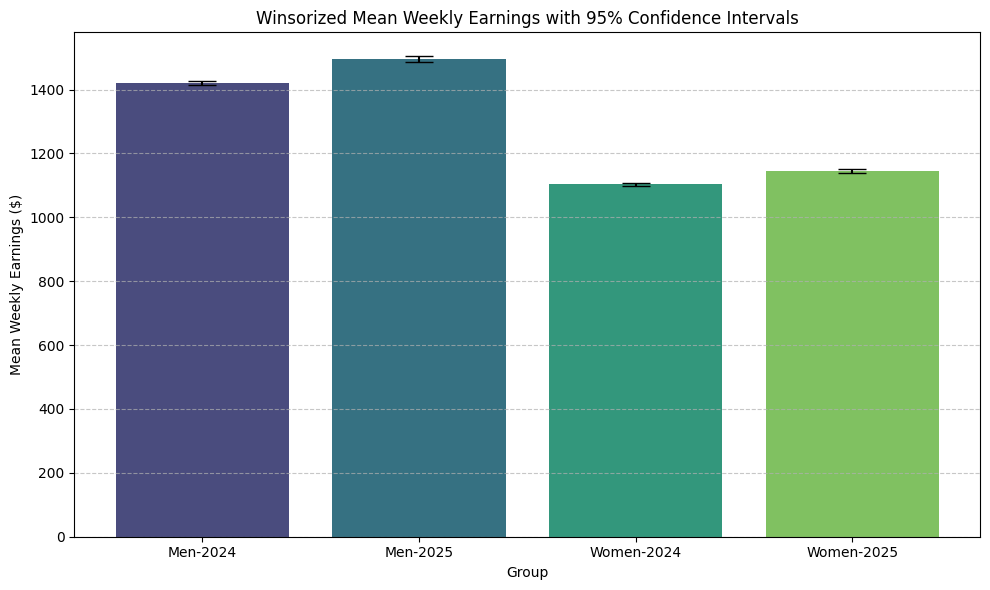

In [65]:
# Prepare data for plotting from the existing summary_df
plot_df = summary_df.copy()

# Add the mean earnings for each group to the plot_df
plot_df['Mean Earnings'] = [
    men_2024_mean, men_2025_mean, women_2024_mean, women_2025_mean
]

# Calculate the error for the error bars (mean - lower_ci and upper_ci - mean)
plot_df['Error_Lower'] = plot_df['Mean Earnings'] - plot_df['Conf. Int. Lower']
plot_df['Error_Upper'] = plot_df['Conf. Int. Upper'] - plot_df['Mean Earnings']

plt.figure(figsize=(10, 6))
# Create the bar plot without errorbar parameter as we'll add them manually
ax = sns.barplot(
    x='Group',
    y='Mean Earnings',
    data=plot_df,
    palette='viridis'
)

# Add error bars manually
x_coords = np.arange(len(plot_df))
y_values = plot_df['Mean Earnings']
yerr_lower = plot_df['Error_Lower']
yerr_upper = plot_df['Error_Upper']

ax.errorbar(
    x=x_coords,
    y=y_values,
    yerr=[yerr_lower, yerr_upper],
    fmt='none',       # No line connecting the error points
    capsize=10,        # Size of the error bar caps
    color='black'     # Color of the error bars
)

plt.title('Winsorized Mean Weekly Earnings with 95% Confidence Intervals')
plt.xlabel('Group')
plt.ylabel('Mean Weekly Earnings ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Two things in particular jump out from this plot. First, there is a sizeable difference between the mean earnings of men and women in both 2024 and 2025. Second, the confidence interval is very small relative to each bar, showing that we were able to make a very accurate confidence interval.